In [2]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages #a reducer used to add messages to the state rather than replacing
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode, tools_condition

import os 
import sys
sys.path.append(os.path.abspath(".."))
from dotenv import load_dotenv
load_dotenv()

c:\Users\davis\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


True

In [3]:
class State(TypedDict):
    #Messages have the type "list". The "add_messages" function
    #in the annotation defines how this state key should be updated
    #(in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

In [4]:
llm = ChatOpenAI(
    model = "gpt-3.5-turbo"
)

In [5]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results = 2)
tool.invoke("What is Langgraph")

{'query': 'What is Langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://huggingface.co/learn/agents-course/en/unit2/langgraph/when_to_use_langgraph',
   'title': 'What is LangGraph',
   'content': '`LangGraph` is a framework developed by LangChain **to manage the control flow of applications that integrate an LLM**. ## Is LangGraph different from LangChain ? The classes from LangChain might be used in LangGraph, but do not HAVE to be used. The packages are different and can be used in isolation, but, in the end, all resources you will find online use both packages hand in hand. `LangGraph` is on the other end of the spectrum, it shines when you need **“Control”** on the execution of your agent. LangGraph is particularly valuable when you need **Control over your applications**. It gives you the tools to build an application that follows a predictable process while still leveraging the power of LLMs. Put simply, if your application invo

In [6]:
#custom function
def multiply(a:int, b:int) -> int:
    """ Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
    int: output int
    """
    return a*b

In [7]:
tools = [tool, multiply]

In [8]:
llm_with_tools = llm.bind_tools(tools)

In [9]:
llm_with_tools

RunnableBinding(bound=ChatOpenAI(profile={'max_input_tokens': 16385, 'max_output_tokens': 4096, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': False, 'structured_output': False, 'image_url_inputs': False, 'pdf_inputs': False, 'pdf_tool_message': False, 'image_tool_message': False, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x0000017EFC81A3C0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000017EFC81AE40>, root_client=<openai.OpenAI object at 0x0000017EFB673770>, root_async_client=<openai.AsyncOpenAI object at 0x0000017EFC81ABA0>, model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engin

In [10]:
#tool definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [11]:
#Graph
graph_builder = StateGraph(State)

#add nodes
graph_builder.add_node("tools_calling_llm", tool_calling_llm)
graph_builder.add_node("tools", ToolNode(tools))

#add edges
graph_builder.add_edge(START, "tools_calling_llm")
graph_builder.add_conditional_edges(
    "tools_calling_llm",
    tools_condition
)
#if the latest message (result) from assistant is a tool call -> tools_condition routes to tools
#if the latest message (result) from assistant is not a tool call -> tools_conditon routes to END
graph_builder.add_edge("tools", END)

In [12]:
#compile the graph
graph = graph_builder.compile()

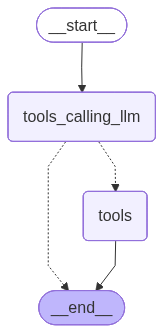

In [13]:
#visualize the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))

except Exception:
    pass

In [14]:
response = graph.invoke({"messages":"What is the recent AI news"})

In [15]:
response["messages"][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://zamin.uz/en/technology/201110-can-artificial-intelligence-develop-itself.html", "title": "Сунъий интеллект ўзини ўзи ривожлантира оладими? - Zamin.uz", "score": 0.6601948, "published_date": "Thu, 14 May 2026 19:57:58 GMT", "content": "Uzbekistan\\n World\\n Society\\n Technology\\n Sport\\n Auto\\n Culture\\n Economy\\n\\n Google\\n Apple\\n Yandex\\n\\nSearch system\\n\\n# Can Artificial Intelligence develop itself?\\n\\nRenowned AI expert Richard Socher has launched a new startup, Recursive Superintelligence. Based in San Francisco, the project officially announced its operations after raising $650 million in funding. The team includes prominent researchers such as Peter Norvig and Cresta founder Tim Shi. This is reported by Techcrunch.com .\\n\\nWithin the project, experts are working on creating a self-improving AI model. Such a system can identify its own weaknesses

In [16]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_LeZoMYH57LXJizteWiOoEVuz)
 Call ID: call_LeZoMYH57LXJizteWiOoEVuz
  Args:
    query: recent AI news
    search_depth: advanced
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://zamin.uz/en/technology/201110-can-artificial-intelligence-develop-itself.html", "title": "Сунъий интеллект ўзини ўзи ривожлантира оладими? - Zamin.uz", "score": 0.6601948, "published_date": "Thu, 14 May 2026 19:57:58 GMT", "content": "Uzbekistan\n World\n Society\n Technology\n Sport\n Auto\n Culture\n Economy\n\n Google\n Apple\n Yandex\n\nSearch system\n\n# Can Artificial Intelligence develop itself?\n\nRenown

In [17]:
response = graph.invoke({"messages": "What is 2 multiplied by 456"})

In [18]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiplied by 456
================================== Ai Message ==================================
Tool Calls:
  multiply (call_dklsEAXwIBSnOnWqFyUEQiVc)
 Call ID: call_dklsEAXwIBSnOnWqFyUEQiVc
  Args:
    a: 2
    b: 456
================================= Tool Message =================================
Name: multiply

912


In [19]:
response = graph.invoke({"messages": "What is 2 multiplied by 4, then multiplied by 10"})

In [20]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiplied by 4, then multiplied by 10
================================== Ai Message ==================================
Tool Calls:
  multiply (call_Nd5YmWx50jVGTlJm4UDHG4NA)
 Call ID: call_Nd5YmWx50jVGTlJm4UDHG4NA
  Args:
    a: 2
    b: 4
================================= Tool Message =================================
Name: multiply

8


In [21]:
response = graph.invoke({"messages": "Give me the recent ai news, and then multiply 5 by 10"})

In [22]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news, and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_UaZzPBomWJPqnZvTG0CuKLV8)
 Call ID: call_UaZzPBomWJPqnZvTG0CuKLV8
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: week
    topic: news
  multiply (call_GmcKxtVIMYF3QpthmW6Bv1VJ)
 Call ID: call_GmcKxtVIMYF3QpthmW6Bv1VJ
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://cyberscoop.com/ai-autonomous-cyber-capability-benchmarks-broken-gpt5-claude-mythos/", "title": "Researchers say AI just broke every benchmark for autonomous cyber capability - CyberScoop", "score": 0.84594244, "published_date": "Wed, 13 May 2026 22:29:19 GM

In [23]:
response

{'messages': [HumanMessage(content='Give me the recent ai news, and then multiply 5 by 10', additional_kwargs={}, response_metadata={}, id='9f426e98-fee3-441d-8d01-0f0948c039f4'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 1298, 'total_tokens': 1362, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DgtZkVTZ0mFI2MHX8shV0O4bPpkOP', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e3b90-adce-7de2-89da-d20c245d898e-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'recent AI news', 'search_depth': 'advanced', 'time_range': 'week', 'topic': 'news'}, 'id': 'call_UaZzPBomWJPqnZvTG0CuKLV8